In [1]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

In [2]:
# df = pd.read_csv('./dataset/Predict Hair Fall.csv')
# df.head()

In [3]:
# print(df.isnull().sum())

In [4]:
# binary_cols = [
#     'Genetics', 
#     'Hormonal Changes', 
#     'Poor Hair Care Habits ', 
#     'Environmental Factors', 
#     'Smoking', 
#     'Weight Loss '
# ]

# # Define the mapping: 'Yes' to 1, 'No' to 0
# mapping = {'Yes': 1, 'No': 0}

# for col in binary_cols:
#     df[col] = df[col].replace(mapping)

# df.head()

In [5]:
# HIGH_CARDINALITY_COLS = [
#     'Medical Conditions', 
#     'Medications & Treatments', 
#     'Nutritional Deficiencies '
# ]

# # Combine any category that appears in less than 5% of the data into 'RARE'.
# RARITY_THRESHOLD = 0.05 
# MISSING_VALUE_STR = 'No Data'

# def group_rare_categories(df, column, threshold, missing_str):
#     """
#     Groups categories that are below a certain frequency threshold into a 
#     'RARE' group and standardizes missing values.
#     """
#     # print(f"Processing column: {column}")
    
#     df[column] = df[column].replace(missing_str, 'MISSING')
    
#     # value_counts = df[column].value_counts(normalize=True)
#     # rare_categories = value_counts[value_counts < threshold].index.tolist()
#     # print(f"Old unique values for {column}: {df[column].nunique()}")
#     # df[column] = df[column].replace(rare_categories, 'RARE')
#     # print(f"New unique values for {column}: {df[column].nunique()}")
#     # print(df[column].value_counts(normalize=True).round(3))
#     # print("-" * 50)
    
#     return df

# for col in HIGH_CARDINALITY_COLS:
#     df = group_rare_categories(df, col, RARITY_THRESHOLD, MISSING_VALUE_STR)

In [6]:
# stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
# df['Stress'] = df['Stress'].replace(stress_mapping).astype(int)

In [7]:
# df['Age_Group'], age_bins = pd.qcut(
#     df['Age'], 
#     q=4, 
#     labels=False, 
#     duplicates='drop',
#     retbins=True
# )

# lowest_age = df['Age'].min()
# highest_age = df['Age'].max()
# print(f"The minimum age in the dataset is: {lowest_age}")
# print(f"The maximum age in the dataset is: {highest_age}")

# # Convert the bins array into readable ranges
# bin_ranges = []
# for i in range(len(age_bins) - 1):
#     # Format the range as [Lower Bound, Upper Bound]
#     lower = round(age_bins[i], 1)
#     upper = round(age_bins[i+1], 1)
#     bin_ranges.append(f"Bin {i}: ({lower} to {upper}]")

# print("--- AGE GROUP BINS (QUARTILES) ---")
# for range_str in bin_ranges:
#     print(range_str)
# print("-" * 50)

# Replace the original 'Age' column with the new binned feature
# df = df.drop(columns=['Age']) 

In [8]:
# df.head()

In [9]:
# sns.pairplot(df, height=3.5)
# plt.tight_layout()
# plt.show()

In [10]:
# selected_features_for_heatmap = ['Genetics', 'Hormonal Changes', 'Stress', 'Age_Group', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 'Weight Loss ', 'Hair Loss']
# correlation_matrix = df[selected_features_for_heatmap].corr()

# plt.figure(figsize=(10, 8))

# heatmap = sns.heatmap(
#     correlation_matrix,
#     annot=True,
#     cmap='coolwarm',
#     fmt='.2f',
#     linewidths=.5,
#     linecolor='black',
#     cbar_kws={'label': 'Correlation Coefficient'}
# )

# plt.title('Correlation Heatmap of Dataset Features', fontsize=16)
# plt.xticks(rotation=45, ha='right')
# plt.yticks(rotation=0)

# plt.tight_layout()
# print("\nDisplaying the heatmap plot... Close the plot window to continue.")
# plt.show()



In [11]:
# #One-hot encode Medical Conditions, Medications & TreatMents, Nutritional Deficiencies
# df = pd.get_dummies(df, columns=['Medical Conditions', 'Medications & Treatments','Nutritional Deficiencies '])
# df = df.astype(np.float32)

In [12]:
# # Define features and target
# features = [item for item in list(df.columns) if item not in ['Id','Hair Loss','Age']]
# #features =  ['Genetics', 'Hormonal Changes', 'Weight Loss ', 'Stress']

# #Check dataset before splitting
# print(features)
# df.head()

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COLUMN = 'Hair Loss'
FILE_PATH = './dataset/Predict Hair Fall.csv' 

try:
    df = pd.read_csv(FILE_PATH)
    print(f"Successfully loaded data from: {FILE_PATH}")
    print(f"Initial shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at '{FILE_PATH}'. Please ensure your file path is correct.")
    exit()

# Drop the non-predictive Id column
df = df.drop('Id', axis=1, errors='ignore') 

# --- 1. Encoding and Feature Engineering ---

binary_cols = [
    'Genetics', 
    'Hormonal Changes', 
    'Poor Hair Care Habits ',
    'Environmental Factors', 
    'Smoking', 
    'Weight Loss '
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})
        df[col] = df[col].fillna(0).astype(int) 

# One-Hot Encoding
stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
if 'Stress' in df.columns:
    df['Stress'] = df['Stress'].map(stress_mapping)
    df['Stress'] = df['Stress'].fillna(1).astype(int)

multi_value_cols = ['Medical Conditions', 'Nutritional Deficiencies ', 'Medications & Treatments'] 

for col in multi_value_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'[\[\]\"]', '', regex=True).fillna('')
        clean_col_name = col.strip().split(" ")[0].capitalize()
        new_count_col = f'Num_{clean_col_name}_Count'
        
        df[new_count_col] = df[col].apply(
            lambda x: len([item.strip() for item in x.split(',') if item.strip() != ''])
        )
        
        df = df.drop(col, axis=1)

if 'Age' in df.columns and 'Genetics' in df.columns and 'Poor Hair Care Habits ' in df.columns and 'Smoking' in df.columns:
    
    df['Age_x_Genetics'] = df['Age'] * df['Genetics']
    df['Smoking_x_PoorHairCare'] = df['Smoking'] * df['Poor Hair Care Habits ']


numerical_cols = ['Age', 'Num_Medical_Count', 'Num_Nutritional_Count', 'Num_Medications_Count', 'Age_x_Genetics'] 
scaler = StandardScaler()

for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())
        # Apply scaling
        df[[col]] = scaler.fit_transform(df[[col]])


columns_to_drop_final = [
    # 'Stress', 
    # 'Hormonal Changes', 
    # 'Environmental Factors', 
    'Poor Hair Care Habits ',
    'Smoking',
    'Age'
]

print(f"\n--- Feature Removal: Dropping {len(columns_to_drop_final)} weak features (r < 0.03) ---")
df = df.drop(columns=columns_to_drop_final, errors='ignore')

# Data Split

if TARGET_COLUMN not in df.columns:
    print(f"\nERROR: Target column '{TARGET_COLUMN}' not found. Please check the name.")
    exit()

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

print("\n--- Preprocessing Complete ---")
print(f"Shape of X_train (Features for Training): {X_train.shape}")
print("\nFirst 5 rows of the NEW training data (X_train):")
print(X_train.head())
print("\nVerify that all remaining columns are numerical (0, 1, or scaled floats):")
print(X_train.dtypes)

Successfully loaded data from: ./dataset/Predict Hair Fall.csv
Initial shape: (999, 13)

--- Feature Removal: Dropping 3 weak features (r < 0.03) ---

--- Preprocessing Complete ---
Shape of X_train (Features for Training): (799, 10)

First 5 rows of the NEW training data (X_train):
     Genetics  Hormonal Changes  Stress  Environmental Factors  Weight Loss   \
761         0                 1       1                      0             1   
77          0                 1       2                      0             1   
813         1                 1       2                      0             1   
756         1                 1       1                      0             0   
975         1                 1       2                      1             0   

     Num_Medical_Count  Num_Nutritional_Count  Num_Medications_Count  \
761                0.0                    0.0                    0.0   
77                 0.0                    0.0                    0.0   
813                

In [14]:
features = [item for item in list(df.columns) if item not in ['Id','Hair Loss','Age']]
X = df[features]
y = df['Hair Loss']

# First split: separate test set (10% of data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

In [15]:
#install necessary libraries
#pytorch
import torch
import torch.nn as nn
import torch.optim as optim

#helper libraries
from torch.utils.data import DataLoader
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.model_selection import learning_curve

%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [16]:
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (899, 10) (899,)
Test set shape: (100, 10) (100,)


In [17]:
from sklearn.neural_network import MLPClassifier

oneLayerModels = {
    'One Layer-16 NN': MLPClassifier(hidden_layer_sizes=(16), max_iter=15000, random_state=42),
    'One Layer-32 NN': MLPClassifier(hidden_layer_sizes=(32), max_iter=15000, random_state=42),
    'One Layer-64 NN': MLPClassifier(hidden_layer_sizes=(64), max_iter=15000, random_state=42),
    'One Layer-128 NN': MLPClassifier(hidden_layer_sizes=(128), max_iter=15000, random_state=42)
}

twoLayerModels = {
    'Two Layer-32-16 NN': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=15000, random_state=42),
    'Two Layer-64-32 NN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=15000, random_state=42),
    'Two Layer-64-16 NN': MLPClassifier(hidden_layer_sizes=(64, 16), max_iter=15000, random_state=42),
}

threeLayerModels = {
    'Three Layer-64-32-16 NN': MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=15000, random_state=42),
    'Three Layer-128-64-32 NN': MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=15000, random_state=42),
    'Three Layer-256-128-64 NN': MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=15000, random_state=42),
    'Three Layer-64-64-64 NN': MLPClassifier(hidden_layer_sizes=(64, 64, 64), max_iter=15000, random_state=42),

}

fiveLayerModels = {
    '5 layer-64-32-16-8-4 NN': MLPClassifier(hidden_layer_sizes=(64, 32, 16, 8, 4), max_iter=15000, random_state=42),
    '5 layer-128-64-32-16-8 NN': MLPClassifier(hidden_layer_sizes=(128, 64, 32, 16, 8), max_iter=15000, random_state=42),
    '5 layer-256-128-64-32-16 NN': MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32, 16), max_iter=15000, random_state=42),    
    '5 layer 64-64-64-64-64 NN': MLPClassifier(hidden_layer_sizes=(64, 64, 64, 64, 64), max_iter=15000, random_state=42)
}

models = oneLayerModels.copy()
models.update(twoLayerModels)
models.update(threeLayerModels)
models.update(fiveLayerModels)

modelVariations = [oneLayerModels, twoLayerModels, threeLayerModels, fiveLayerModels]

for name, model in models.items():
    model.fit(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    auc = roc_auc_score(y_test, model.predict(X_test))
    f1 = f1_score(y_test, model.predict(X_test))
    print(f'{name} Test Accuracy: {test_acc:.4f}, AUC: {auc:.4f}, F1 Score: {f1:.4f}')

One Layer-16 NN Test Accuracy: 0.5500, AUC: 0.5500, F1 Score: 0.6087
One Layer-32 NN Test Accuracy: 0.5200, AUC: 0.5200, F1 Score: 0.5294
One Layer-64 NN Test Accuracy: 0.5300, AUC: 0.5300, F1 Score: 0.5437
One Layer-128 NN Test Accuracy: 0.4900, AUC: 0.4900, F1 Score: 0.5321
Two Layer-32-16 NN Test Accuracy: 0.5000, AUC: 0.5000, F1 Score: 0.5283
Two Layer-64-32 NN Test Accuracy: 0.5000, AUC: 0.5000, F1 Score: 0.5000
Two Layer-64-16 NN Test Accuracy: 0.5100, AUC: 0.5100, F1 Score: 0.5333
Three Layer-64-32-16 NN Test Accuracy: 0.5200, AUC: 0.5200, F1 Score: 0.5789
Three Layer-128-64-32 NN Test Accuracy: 0.5300, AUC: 0.5300, F1 Score: 0.5841
Three Layer-256-128-64 NN Test Accuracy: 0.5300, AUC: 0.5300, F1 Score: 0.5841
Three Layer-64-64-64 NN Test Accuracy: 0.5700, AUC: 0.5700, F1 Score: 0.5825
5 layer-64-32-16-8-4 NN Test Accuracy: 0.5600, AUC: 0.5600, F1 Score: 0.5510
5 layer-128-64-32-16-8 NN Test Accuracy: 0.5300, AUC: 0.5300, F1 Score: 0.5607
5 layer-256-128-64-32-16 NN Test Accurac

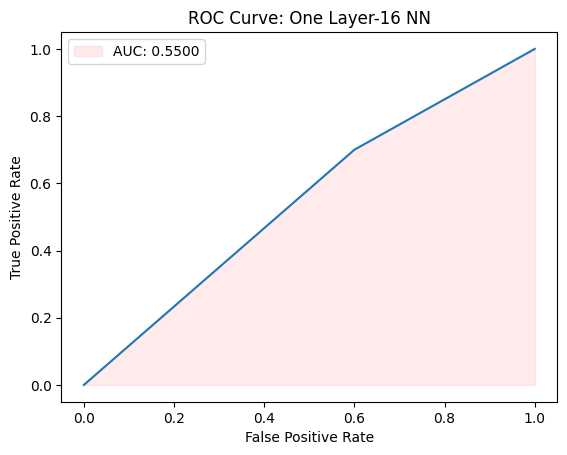

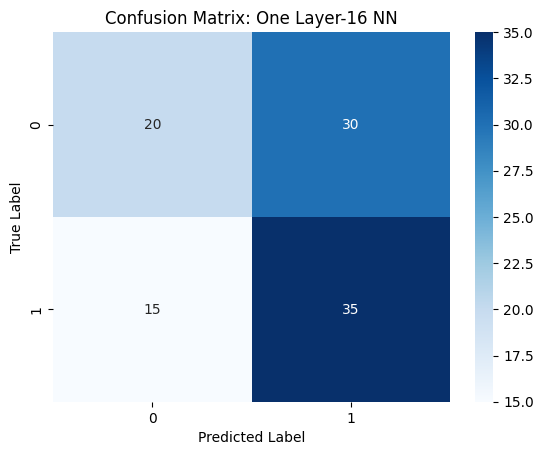

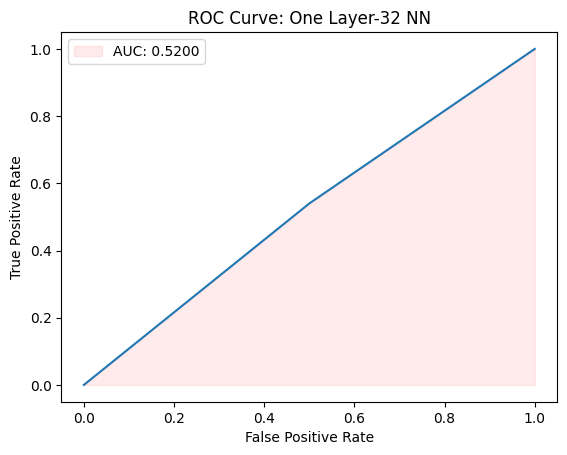

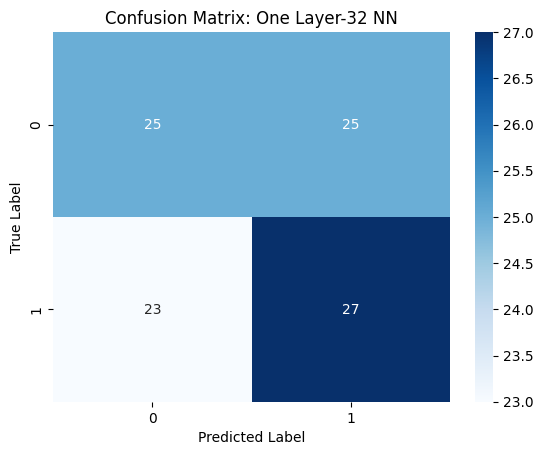

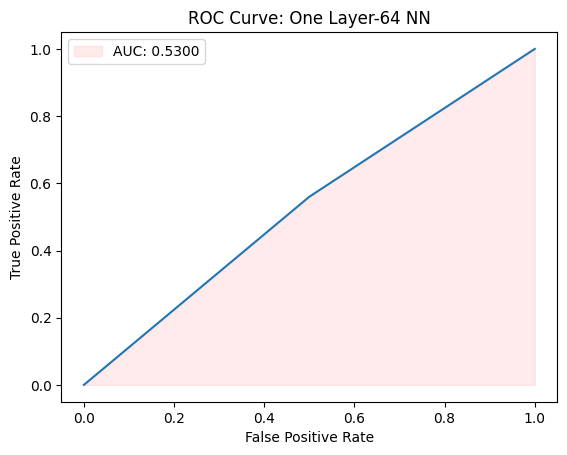

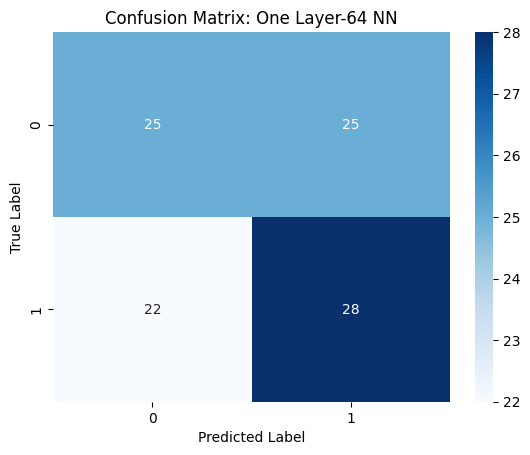

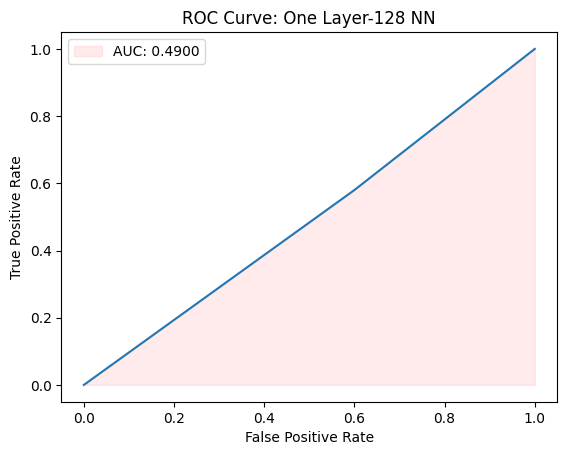

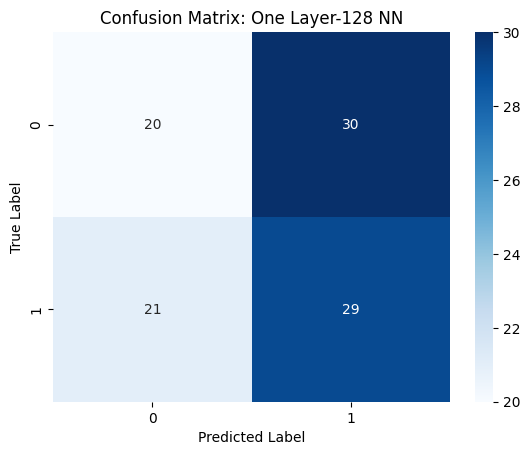

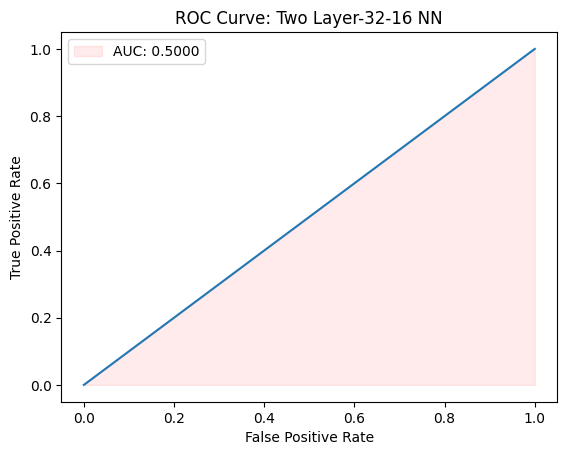

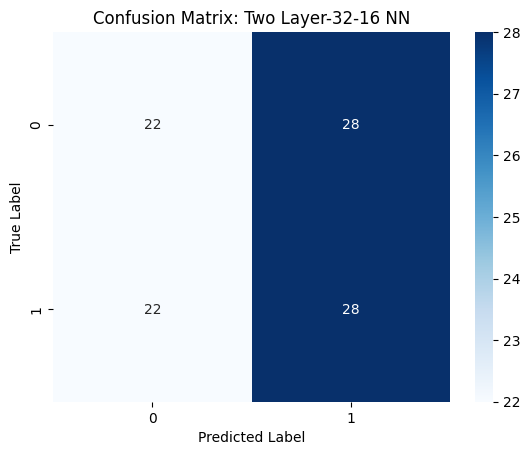

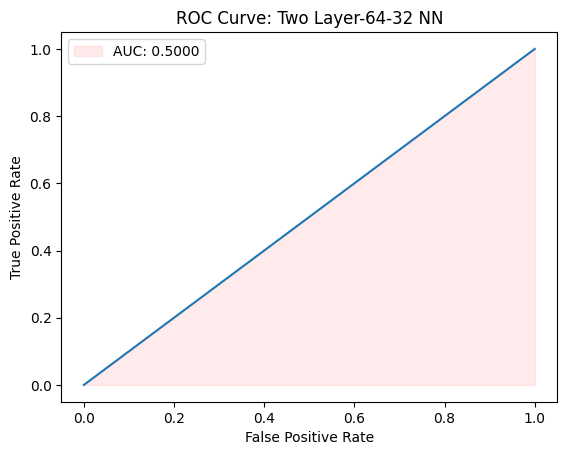

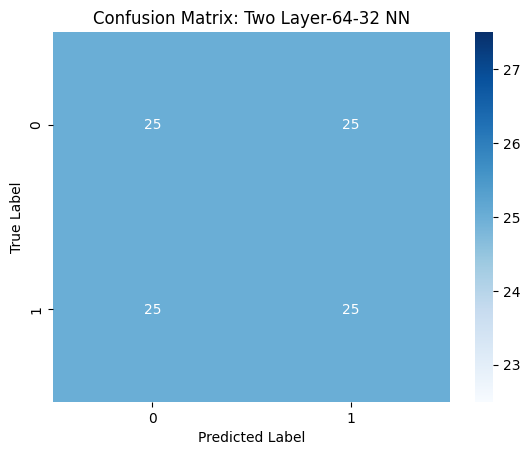

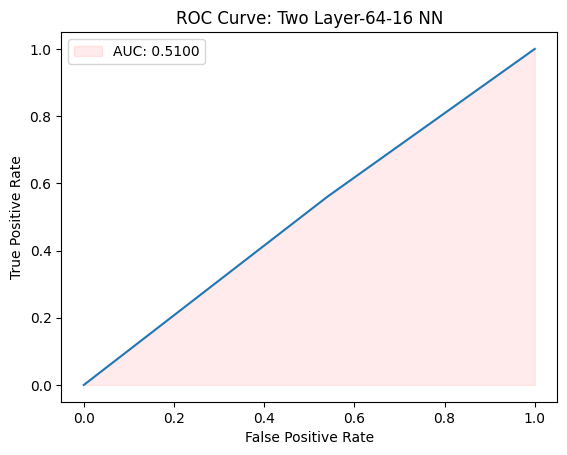

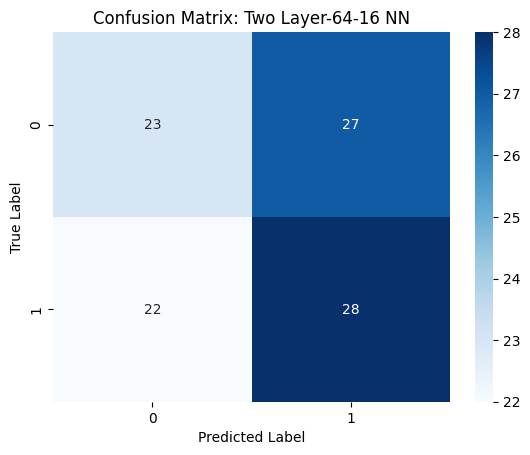

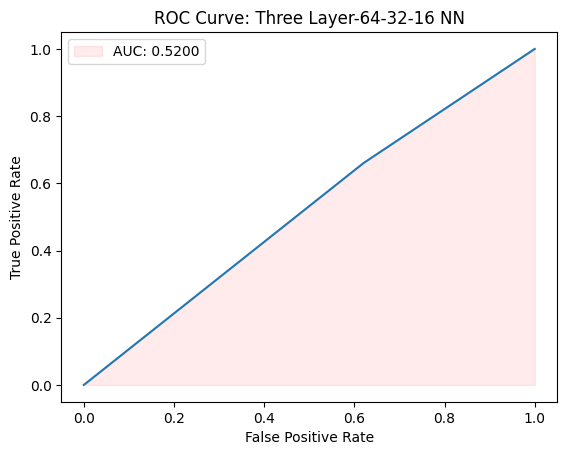

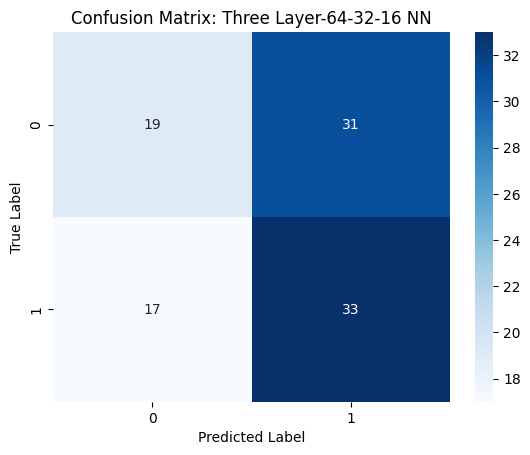

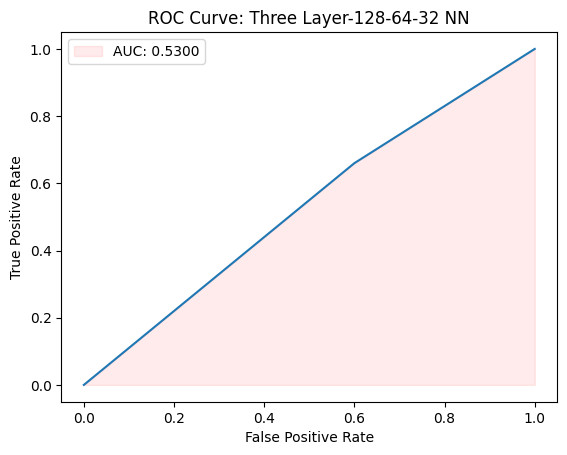

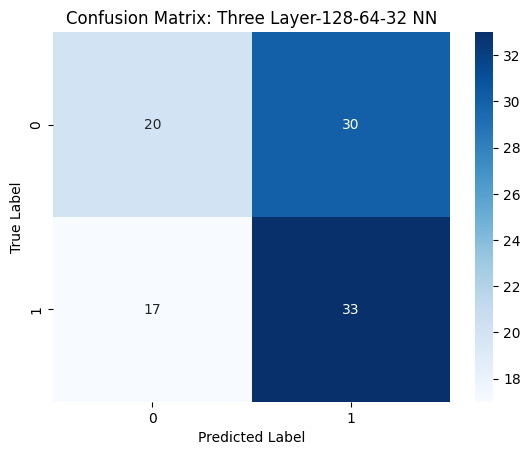

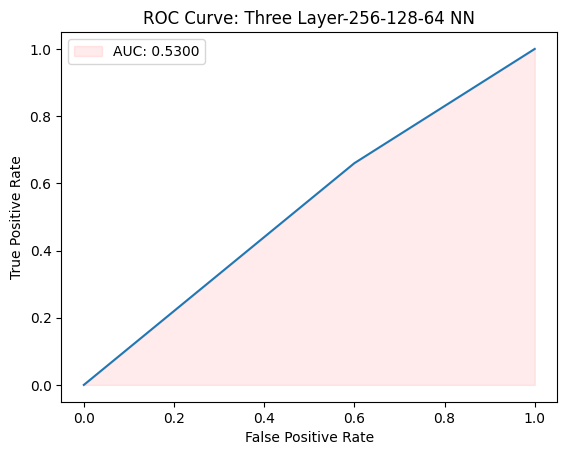

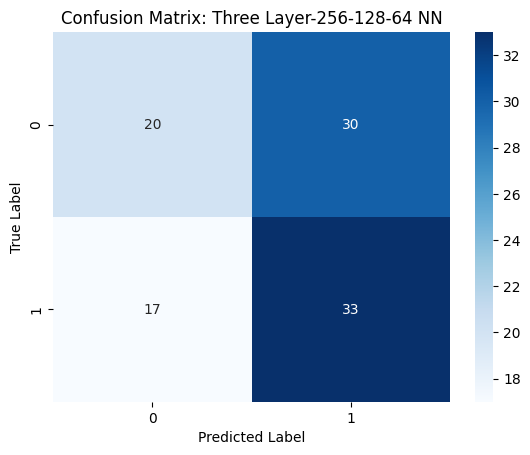

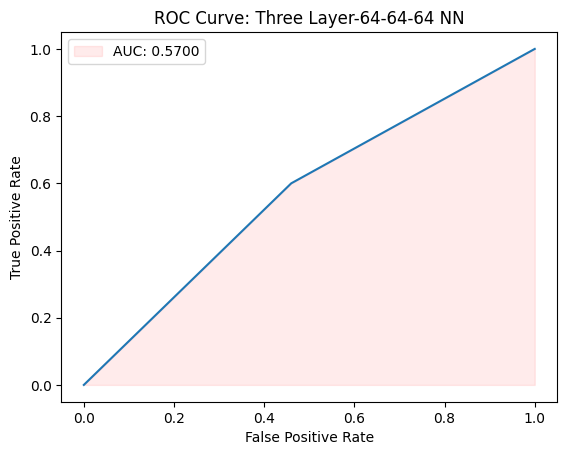

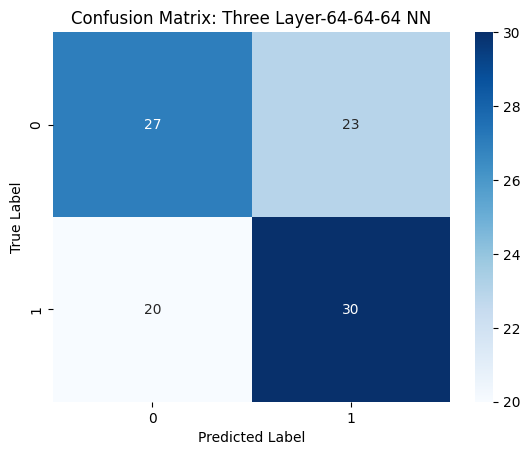

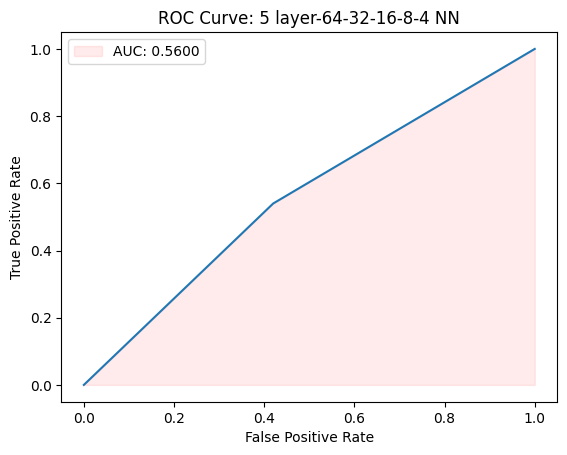

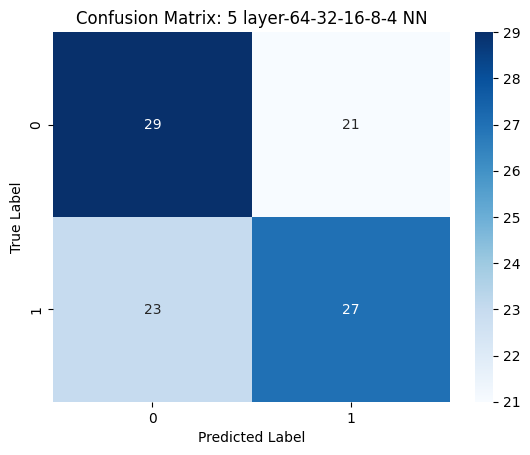

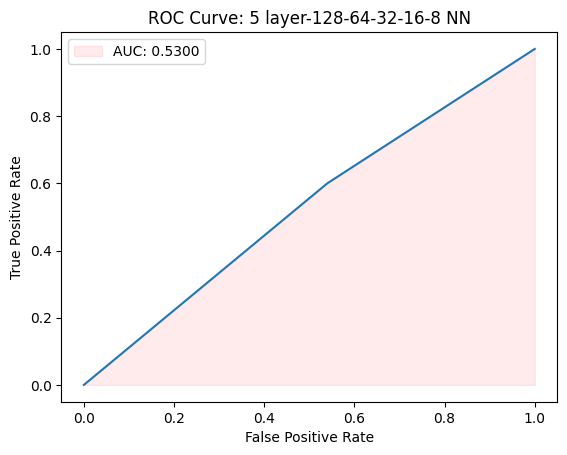

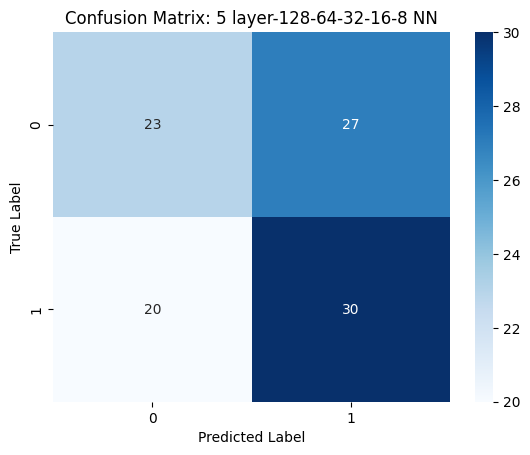

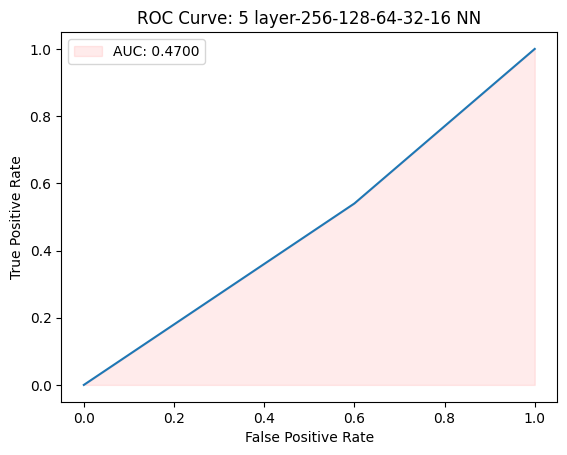

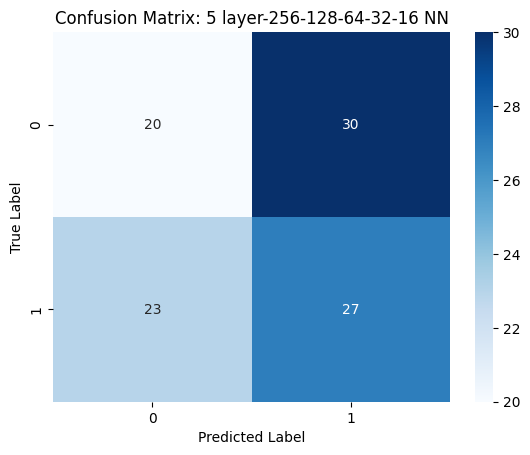

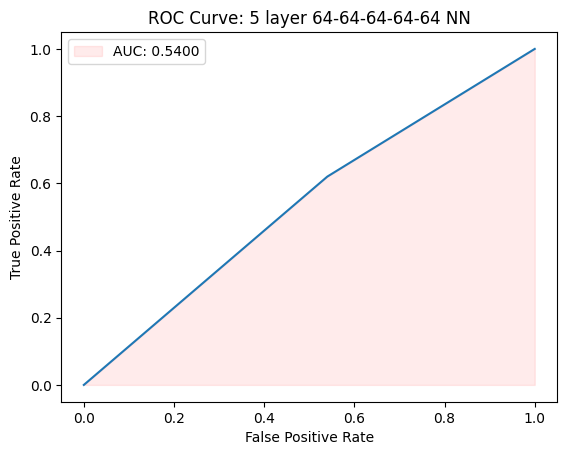

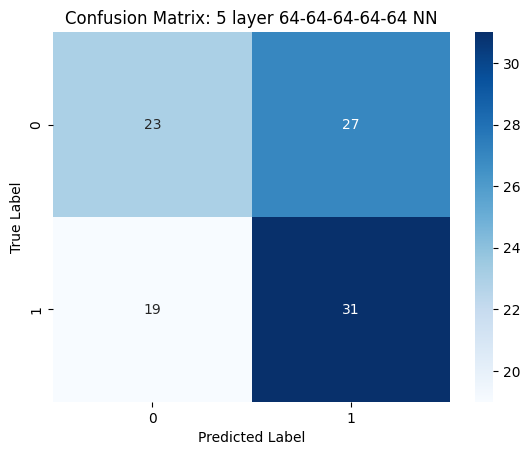

In [18]:
for name, model in models.items():
    fpr, tpr, thresholds = roc_curve(y_test, model.predict(X_test))
    auc = roc_auc_score(y_test, model.predict(X_test))
    auc =  "AUC: " + str(f"{auc:.4f}")
    plt.plot(fpr, tpr)
    plt.fill_between(fpr, tpr, color='red', alpha=0.08,label=auc)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve: ' + name)
    plt.legend()
    plt.show()

    cm = confusion_matrix(y_test, model.predict(X_test))
    ax = sns.heatmap(cm, fmt='d',annot=True, cmap='Blues')
    ax.set(xlabel ="Predicted Label", ylabel = 'True Label', title ='Confusion Matrix: ' + name)
    plt.show()

In [19]:
def drawLearningCurve(models, X, y):
    for ax, (name, model) in zip(axes, models.items()):
        train_sizes, train_scores, test_scores = learning_curve(
                model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
                train_sizes=np.linspace(0.1, 1.0, 10)
            )
        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        ax.plot(train_sizes, train_mean, 'o-', label='Training score')
        ax.plot(train_sizes, test_mean, 'o-', label='Cross-validation score')
        ax.axhline(y=0.94,c='r',ls='--')
        ax.set_title(name)
        ax.set_xlabel('Training examples')
        ax.set_ylabel('Accuracy')
        ax.grid(True)
    handles, labels = ax.get_legend_handles_labels()  # use last subplot to get handles
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=[0.5,-0.025], ncol=2, fontsize=12)
    fig.suptitle('Learning Curves: Variations of Neural Network Architectures', fontsize=14)
    plt.show()


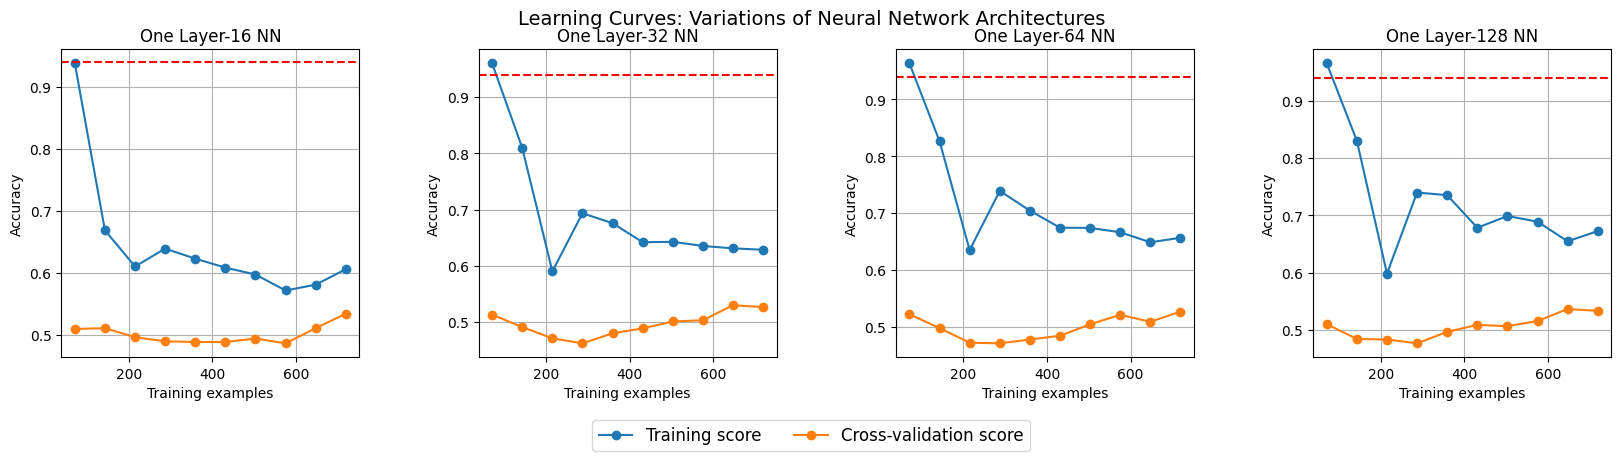

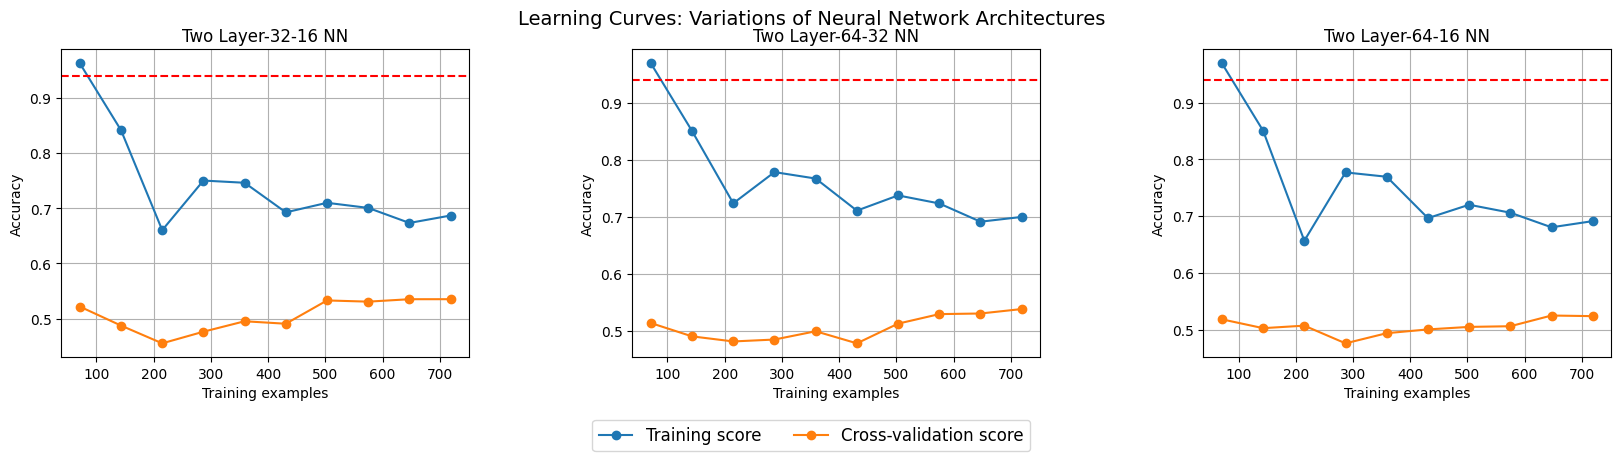

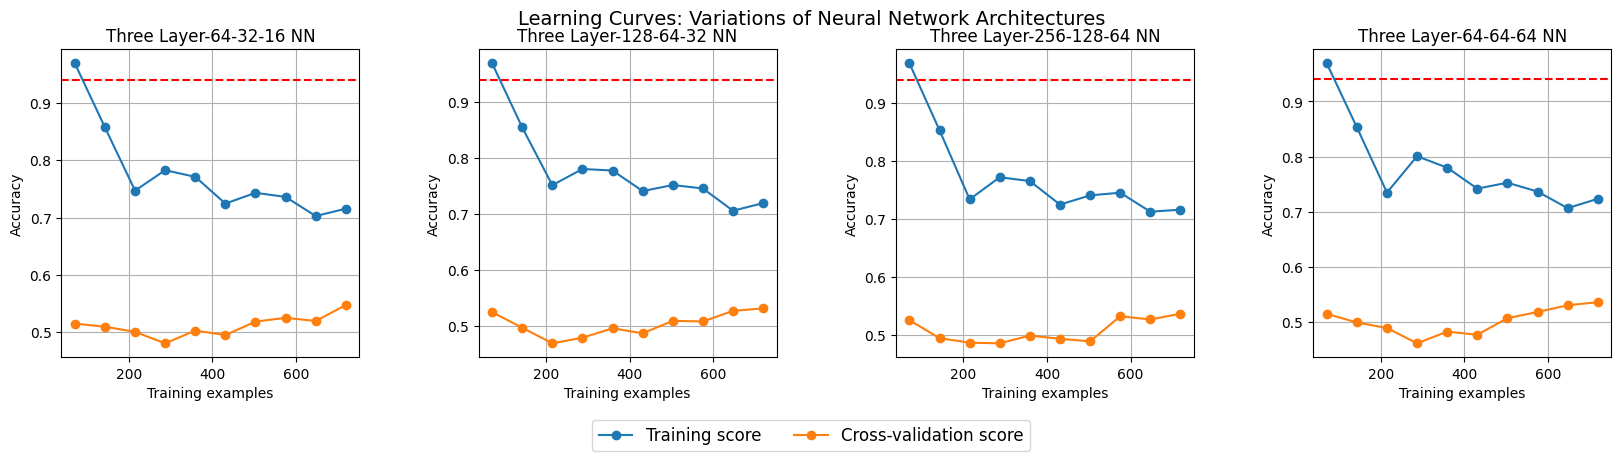

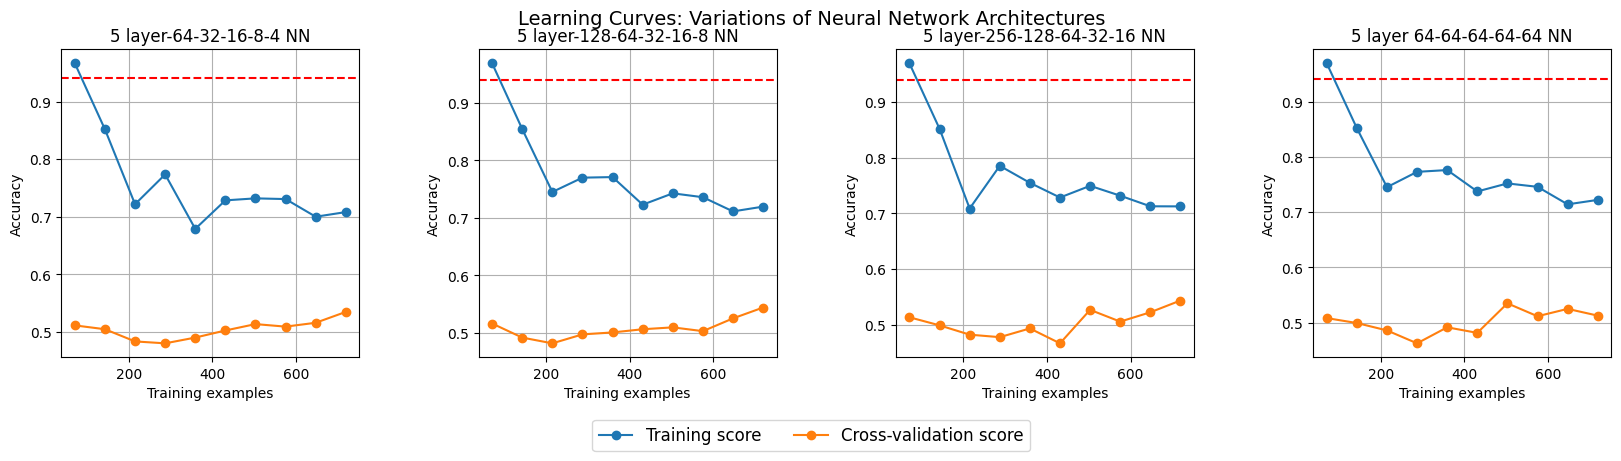

In [20]:
for modelVariation in modelVariations:
    fig, axes = plt.subplots(1, len(modelVariation), figsize=(20, 4))
    plt.subplots_adjust(wspace=0.4)
    drawLearningCurve(modelVariation, X_train, y_train)